In [1]:
!pip install av
!pip install torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 47.0 MB/s eta 0:00:00:00:0100:01


In [2]:
import torch 
from torch import nn 
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader, Dataset, Subset
from torchinfo import summary
from torch.optim import Adam 

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from torchvision.datasets import DatasetFolder
from torchvision.io import read_video
from torchvision import transforms
from torchvision.models import resnet50

import os
import cv2
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [5]:
def load_video(path, num_frames=16, size=(128, 128)):
    frames = []
    cap = cv2.VideoCapture(path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames_len = np.linspace(0, total_frames-1, num_frames, dtype=int)

    for i in frames_len:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, size)
        frame = torch.tensor(frame).permute(2, 0, 1)  # [C, H, W]
        frames.append(frame)

    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1])

    return torch.stack(frames, dim=0)

In [6]:
transformer = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomCrop((128, 128)),   
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),                        
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomCrop(128),
])

In [7]:
link = "/kaggle/input/milirary-vehicles-tactics/vehicles_videos"
dataset = DatasetFolder(
    root = link,
    loader = load_video,
    extensions = ("mp4", "avi"),
    transform = transformer
)

In [8]:
def compute_dense_optical_flow(frames):
    """
    Dense Optical Flow (Farneback)

    frames: np.ndarray [T, H, W, 3]
            RGB, uint8
            T >= 2 (у тебя T = 16)

    return:
        flows: np.ndarray [T-1, H, W, 2]
               dx, dy для каждого шага
    """

    assert frames.ndim == 4, "frames must be [T, H, W, 3]"
    assert frames.shape[-1] == 3, "frames must be RGB"

    flows = []

    prev_gray = cv2.cvtColor(frames[0], cv2.COLOR_RGB2GRAY)

    for t in range(1, frames.shape[0]):
        curr_gray = cv2.cvtColor(frames[t], cv2.COLOR_RGB2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev_gray,
            curr_gray,
            None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )

        flows.append(flow)
        prev_gray = curr_gray

    return np.stack(flows, axis=0)

In [11]:
os.makedirs("flow_cache", exist_ok=True)

for idx in tqdm(range(len(dataset))):
    video, label = dataset[idx]

    if isinstance(video, torch.Tensor):
        if video.shape[1] == 3:
            video = video.permute(0, 2, 3, 1)
        video = video.numpy()

    if video.dtype != np.uint8:
        video = (video * 255).astype(np.uint8)

    flows = compute_dense_optical_flow(video)

    dx = flows[..., 0]
    dy = flows[..., 1]
    mag = np.sqrt(dx**2 + dy**2)

    flow_seq = np.stack([
        dx.mean(axis=(1,2)),
        dy.mean(axis=(1,2)),
        mag.mean(axis=(1,2))
    ], axis=1)

    flow_seq = np.clip(flow_seq, -20, 20) / 20.0

    torch.save(
        {
            "x": torch.tensor(flow_seq, dtype=torch.float32),
            "y": label
        },
        f"flow_cache/{idx}.pt"
    )


100%|██████████| 4306/4306 [31:16<00:00,  2.29it/s]


In [8]:
# os.makedirs("flow_cache", exist_ok=True)

# skipped = 0

# for idx in tqdm(range(len(dataset))):
#     video, label = dataset[idx]

#     if isinstance(video, torch.Tensor):
#         video = video.cpu()

#         if video.ndim == 2:
#             skipped += 1
#             continue

#         if video.ndim == 4:
#             # [T, C, H, W]
#             if video.shape[1] == 3:
#                 video = video.permute(0, 2, 3, 1)
#             # [C, T, H, W]
#             elif video.shape[0] == 3:
#                 video = video.permute(1, 2, 3, 0)
#             else:
#                 skipped += 1
#                 continue

#         else:
#             skipped += 1
#             continue

#         video = video.numpy()
        
#     if not isinstance(video, np.ndarray):
#         skipped += 1
#         continue

#     if video.ndim != 4 or video.shape[-1] != 3:
#         skipped += 1
#         continue

#     if video.dtype != np.uint8:
#         video = (video * 255).astype(np.uint8)

#     try:
#         flows = compute_dense_optical_flow(video)  # [15, H, W, 2]
#     except Exception as e:
#         skipped += 1
#         continue

#     dx = flows[..., 0]
#     dy = flows[..., 1]
#     mag = np.sqrt(dx**2 + dy**2)

#     H, W = dx.shape[1:]
#     h2, w2 = H // 2, W // 2

#     def quad_mean(arr):
#         return [
#             arr[:, :h2, :w2].mean(axis=(1, 2)),
#             arr[:, :h2, w2:].mean(axis=(1, 2)),
#             arr[:, h2:, :w2].mean(axis=(1, 2)),
#             arr[:, h2:, w2:].mean(axis=(1, 2)),
#         ]

#     features = []
#     for comp in (dx, dy, mag):
#         features.extend(quad_mean(comp))

#     flow_seq = np.stack(features, axis=1)   # [15, 12]

#     flow_seq = np.clip(flow_seq, -20, 20) / 20.0

#     torch.save(
#         {
#             "x": torch.tensor(flow_seq, dtype=torch.float32),
#             "y": int(label)
#         },
#         f"flow_cache/{idx}.pt"
#     )

# print(f"✅ Done. Skipped samples: {skipped}")


100%|██████████| 4306/4306 [26:49<00:00,  2.67it/s]

✅ Done. Skipped samples: 0


In [14]:
class CachedFlowDataset(Dataset):
    def __init__(self, cache_dir, dataset):
        self.cache_dir = cache_dir
        self.files = sorted(os.listdir(cache_dir))
        self.classes = dataset.classes

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = torch.load(os.path.join(self.cache_dir, self.files[idx]))
        return data["x"], torch.tensor(data["y"])


In [15]:
dataset = CachedFlowDataset("flow_cache", dataset)

indices = np.random.permutation(len(dataset))
split = int(0.9 * len(indices))

train_idx = indices[:split]
val_idx   = indices[split:]

train_data = Subset(dataset, train_idx)
val_data = Subset(dataset, val_idx)


In [16]:
classes = dataset.classes
classes

['back', 'center', 'from_left_flank', 'from_right_flank']

In [17]:
train_data[0][0].shape

torch.Size([15, 3])

In [18]:
x, y = train_data[0]
x.shape

torch.Size([15, 3])

In [19]:
batch_size = 128

train_dl = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4)
val_dl = DataLoader(val_data, batch_size=batch_size, shuffle=True, num_workers=4)

In [20]:
x, y = next(iter(train_dl))
print(x.shape, y.shape)

torch.Size([128, 15, 3]) torch.Size([128])


In [21]:
tensor = torch.randn(64, 15, 3)

layer = nn.LSTM(
    input_size = 3,
    hidden_size = 128, 
    num_layers = 1,
    batch_first = True,
    bidirectional = True
)

out, (h, c) = layer(tensor)
print(out.shape, h.shape, c.shape)

# LSTM block in PyTorch is not only a block, but a sequence of LSTM cells. So if we've got 16 frames in video, we will have 16 cells of LSTM in a network

# -> (torch.Size([1, 16, 1024]), torch.Size([2, 1, 512]), torch.Size([2, 1, 512]))

# where out - is an collection of hidden states (short memory) of each frame - thats why it has 16 frames. 
# It also has a size of 1024 (512 * 2) because block is bidirectional and contains forward and back states 

# h - is a short memory on step t
# c - is a long memory on step t 

# both of them have size of [num_layers * num_directions, B, hidden_size]

torch.Size([64, 15, 256]) torch.Size([2, 64, 128]) torch.Size([2, 64, 128])


In [22]:
class TemporalAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()

        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        weight = self.attn(x)
        weight = torch.softmax(weight, dim=1)

        return (x * weight).sum(dim=1)

In [28]:
class Net(nn.Module):
    def __init__(self, layers=3, hidden_size=256, feature_dim = 3, bidirectional = True, num_classes = 4):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size = feature_dim,
            hidden_size = hidden_size,
            num_layers = layers,
            batch_first = True,
            bidirectional = bidirectional
        )

        out_dim = hidden_size * (2 if bidirectional else 1)

        self.ta = TemporalAttention(out_dim)
        self.classifier = nn.Linear(out_dim, num_classes) 


    def forward(self, x):
        lstm_out, (_, _) = self.lstm(x)
        out = self.ta(lstm_out)

        logits = self.classifier(out)
        return logits

    def predict(self, x):
        self.eval()

        with torch.no_grad():
            out = self.forward(x)

        out = torch.argmax(out, dim=1)
        return out.item()
        

In [29]:
model = Net()
tensor = torch.randn(1, 15, 3)
out = model(tensor)
out.shape

torch.Size([1, 4])

In [30]:
model = Net()
tensor = torch.randn(1, 15, 3)
out = model.predict(tensor)
out

2

In [31]:
summary(model, input_data=torch.randn(1, 15, 3))

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1, 4]                    --
├─LSTM: 1-1                              [1, 15, 512]              3,688,448
├─TemporalAttention: 1-2                 [1, 512]                  --
│    └─Linear: 2-1                       [1, 15, 1]                513
├─Linear: 1-3                            [1, 4]                    2,052
Total params: 3,691,013
Trainable params: 3,691,013
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 55.33
Input size (MB): 0.00
Forward/backward pass size (MB): 0.06
Params size (MB): 14.76
Estimated Total Size (MB): 14.83

In [32]:
model.to(device)

Net(
  (lstm): LSTM(3, 256, num_layers=3, batch_first=True, bidirectional=True)
  (ta): TemporalAttention(
    (attn): Linear(in_features=512, out_features=1, bias=True)
  )
  (classifier): Linear(in_features=512, out_features=4, bias=True)
)

In [34]:
def train(train_dl, val_dl, model, optimizer, loss_fn, accuracy_score, epochs, device):
    history = {
        "train_loss": [],
        "train_acc": [],

        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(epochs):
        
        model.train()
        train_loss = 0.0
        train_acc = 0.0

        for x, y in tqdm(train_dl):
            x = x.to(device).float()
            y = y.to(device)

            optimizer.zero_grad()

            out = model(x)
            loss = loss_fn(out, y)
            train_loss += loss.item()
            
            loss.backward()
            optimizer.step()

            out = out.argmax(dim=1).detach().cpu().numpy()
            y = y.cpu().numpy()

            acc = accuracy_score(out, y)
            train_acc += acc

        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        
        with torch.no_grad():
            for x, y in tqdm(val_dl):
                x = x.to(device).float()
                y = y.to(device)

                out = model(x)
                loss = loss_fn(out, y)
                val_loss += loss.item()

                out = out.argmax(dim=1).detach().cpu().numpy()
                y = y.cpu().numpy()

                acc = accuracy_score(out, y)
                val_acc += acc

        total_train_loss = train_loss / len(train_dl)
        total_train_acc = train_acc / len(train_dl)

        total_val_loss = val_loss / len(val_dl)
        total_val_acc = val_acc / len(val_dl)

        history["train_loss"].append(total_train_loss)
        history["train_acc"].append(total_train_acc)

        history["val_loss"].append(total_val_loss)
        history["val_acc"].append(total_val_acc)

        print(f"Epoch: {epoch+1} | train_loss: {total_train_loss:.4f} | train_acc: {total_train_acc:.4f} | val_loss: {total_val_loss:.4f} | val_acc: {total_val_acc:.4f}")
                
    return history 

In [35]:
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
epochs = 80

In [36]:
history = train(train_dl, val_dl, model, optimizer, loss_fn, accuracy_score, epochs, device)

100%|██████████| 4/4 [00:00<00:00, 20.08it/s]


Epoch: 1 | train_loss: 1.3853 | train_acc: 0.2837 | val_loss: 1.3857 | val_acc: 0.2795


100%|██████████| 4/4 [00:00<00:00, 19.76it/s]


Epoch: 2 | train_loss: 1.3774 | train_acc: 0.2963 | val_loss: 1.3323 | val_acc: 0.3270


100%|██████████| 4/4 [00:00<00:00, 16.80it/s]


...

Epoch: 78 | train_loss: 0.8340 | train_acc: 0.6569 | val_loss: 1.0099 | val_acc: 0.5996


100%|██████████| 4/4 [00:00<00:00, 20.54it/s]


Epoch: 79 | train_loss: 0.7898 | train_acc: 0.6764 | val_loss: 1.0639 | val_acc: 0.5866


100%|██████████| 4/4 [00:00<00:00, 19.63it/s]

Epoch: 80 | train_loss: 0.7479 | train_acc: 0.6952 | val_loss: 1.0235 | val_acc: 0.5870


In [37]:
def output(history, name):
    plt.plot(history[f"train_{name}"], label="Training set")
    plt.plot(history[f"val_{name}"], label="Validation set")
    plt.title(f"Changing of {name}")
    plt.xlabel("epochs")
    plt.ylabel(name)
    plt.legend()

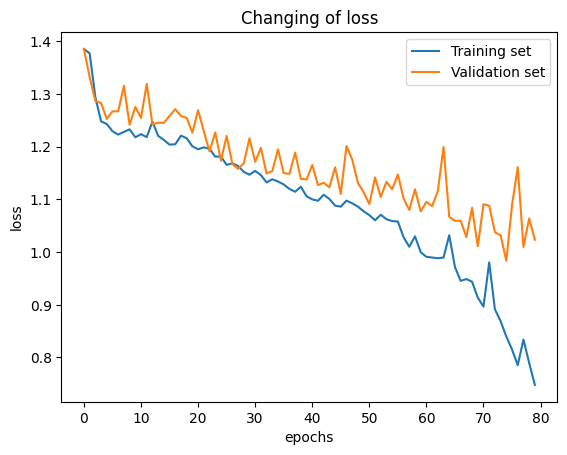

In [38]:
output(history, "loss")

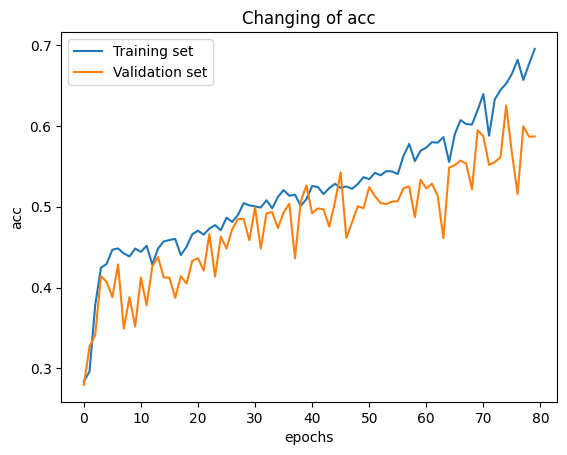

In [39]:
output(history, "acc")

In [43]:
torch.save(model.state_dict(), "optical_tactic_model.pt")

In [40]:
t_model = Net()

link = ""
t_model.load_state_dict(torch.load(link, map_location=device))
t_model.to(device)

100%|██████████| 4/4 [00:00<00:00, 19.73it/s]


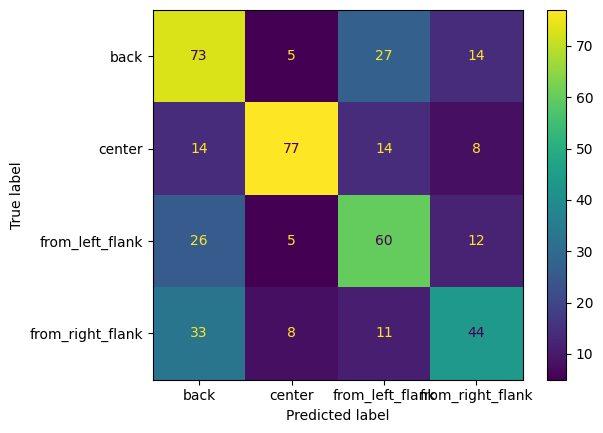

In [41]:
y_preds = []
y_trues = []

model.eval()

with torch.no_grad():
    for x, y in tqdm(val_dl):
        x = x.to(device).float()
        y = y.to(device)

        out = model(x)
        y_pred = torch.argmax(out, dim=1)
        
        y_preds.extend(y_pred.cpu().numpy())
        y_trues.extend(y.cpu().numpy())

y_preds = np.array(y_preds)
y_trues = np.array(y_trues)

ConfusionMatrixDisplay.from_predictions(y_trues, y_preds, labels=np.arange(len(classes)), display_labels=classes)